1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

2. Device Configuration and Seed Initialization

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
 torch.cuda.manual_seed(seed)

3. Load CIFAR-10 Dataset

In [3]:
#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


4. CNN Starter Code

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = torch.sigmoid(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x


5. MLP Starter Code

In [5]:
class InitialMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x


6. Initialize Network

In [6]:
model = InitialCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


7. Training Function

In [7]:
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, gradient_norms


8. Testing Function

In [8]:
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy


9. Main Training Loop

In [9]:
num_epochs = 15

train_losses = []
test_losses = []

train_accs = []
test_accs = []

for epoch in range(num_epochs):

    train_loss, train_acc, grad_norms = train(
        model,
        train_loader
    )

    test_loss, test_acc = test(
        model,
        test_loader
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")

    print("-" * 40)


Epoch 1/15
Train Loss: 2.1462
Train Accuracy: 18.57%
Test Loss: 1.9458
Test Accuracy: 27.08%
----------------------------------------
Epoch 2/15
Train Loss: 1.8762
Train Accuracy: 31.21%
Test Loss: 1.7389
Test Accuracy: 36.90%
----------------------------------------
Epoch 3/15
Train Loss: 1.6954
Train Accuracy: 38.42%
Test Loss: 1.6238
Test Accuracy: 40.86%
----------------------------------------
Epoch 4/15
Train Loss: 1.5639
Train Accuracy: 43.06%
Test Loss: 1.4930
Test Accuracy: 45.45%
----------------------------------------
Epoch 5/15
Train Loss: 1.4508
Train Accuracy: 47.31%
Test Loss: 1.3979
Test Accuracy: 48.74%
----------------------------------------
Epoch 6/15
Train Loss: 1.3739
Train Accuracy: 50.21%
Test Loss: 1.3385
Test Accuracy: 51.35%
----------------------------------------
Epoch 7/15
Train Loss: 1.3073
Train Accuracy: 52.46%
Test Loss: 1.2959
Test Accuracy: 52.70%
----------------------------------------
Epoch 8/15
Train Loss: 1.2545
Train Accuracy: 54.43%
Test Loss

10. Train the MLP

In [ ]:
mlp_model = InitialMLP().to(device)

criterion = nn.CrossEntropy Loss()

optimizer = optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

11. classes = train_dataset.classes

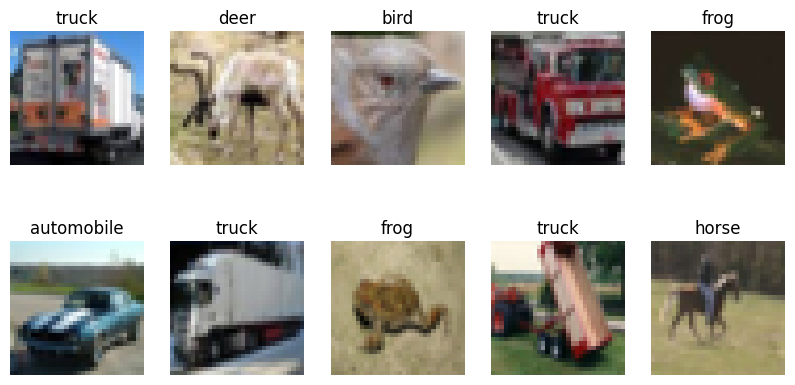

In [11]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):

    img = images[i] / 2 + 0.5
    img = img.permute(1,2,0)

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.show()